<a href="https://colab.research.google.com/github/Caleb-Harper/Caleb_INFO4670_Fall2026/blob/main/INFO4670_Week3_Assignment1_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** \_\_\_\_\_\_\_\_    **Date:** \_\_\_\_\_\_\_\_

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [19]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

 # OPTION 1 · read from Google Drive — uncomment and edit the path:
 # from google.colab import drive
 # drive.mount("/content/drive")
 # DATA_DIR = "/co`ntent/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

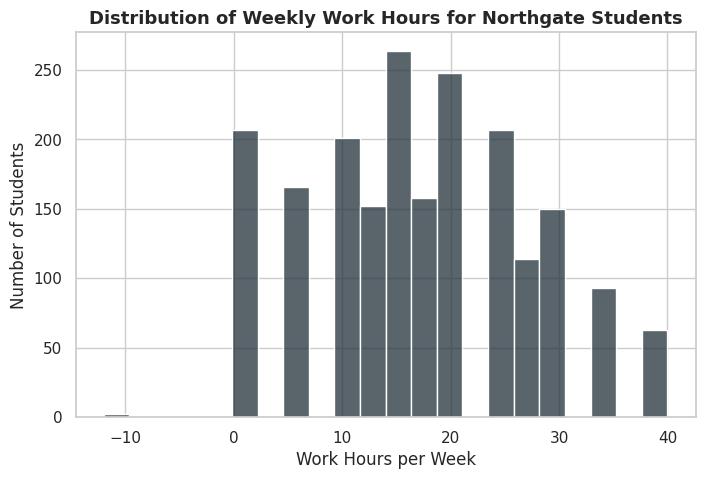

In [31]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.

fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("Distribution of Weekly Work Hours for Northgate Students")
ax.set_xlabel("Work Hours per Week")
ax.set_ylabel("Number of Students")
plt.show()




**STAR story — Q1** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students) This chart shows the amount time students spend at work each week.
- **Track —** which question are you answering? The question asking how many hours students spend at work each week.
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend) It shows that the typical work range is 15-20 hours per week. the distribution is wide and the shape is likely skewed to the right.
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)* Some of the odd things are that some of the kids working low hours have low GPA's and are studying way less hours as well.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

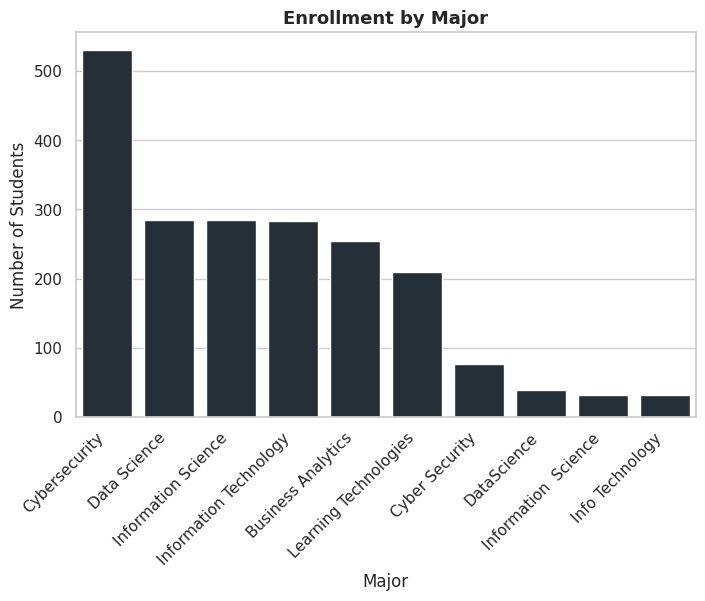

In [39]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.

major_counts = students["major"].value_counts().reset_index()
major_counts.columns = ["major", "count"]

fig, ax = plt.subplots()
sns.barplot(data=major_counts, x="major", y="count", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("Enrollment by Major")
ax.set_xlabel("Major")
ax.set_ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.show()

**STAR story — Q2** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students) It shows the number of students enrolled in each major
- **Track —** which question are you answering? How does enrollment compare across majors? I'm looking for the height of each bar to compare whuch majors have the most students, which have fewer, and whether any majors stand out as unusually large or small.
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend) The shape of the graph has one huge bar, a middle group and a tail of small bars.
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)* Something odd about the graph are all of the duplicates

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

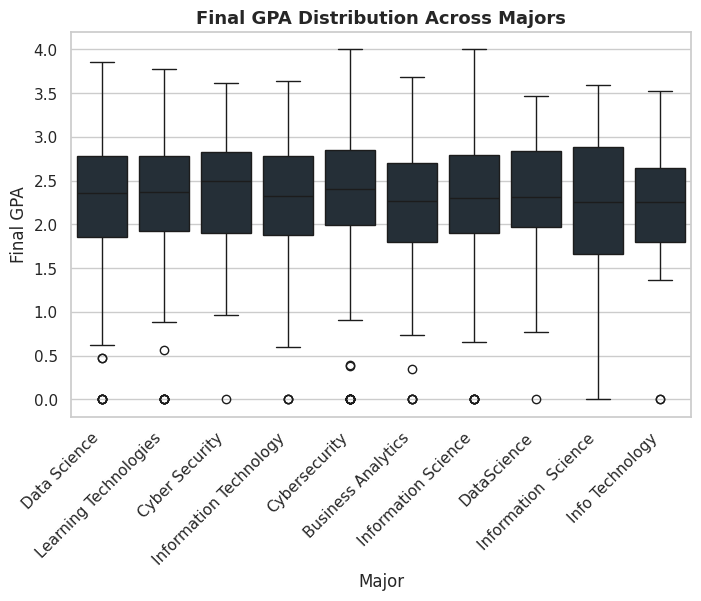

In [40]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
fig, ax = plt.subplots()
sns.boxplot(data=students, x="major", y="final_gpa", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("Final GPA Distribution Across Majors")
ax.set_xlabel("Major")
ax.set_ylabel("Final GPA")
plt.xticks(rotation=45, ha="right")
plt.show()




**STAR story — Q3** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students) This shows the distribution of final GPA values across different majors in the dataset.
- **Track —** which question are you answering? How do GPA outcomes compare across majors? I'm looking for differences in median GPA, the spread of scores, and whether certain majors have more variability or more extreme outliers. This identifies majors where students may be performing well or struggling
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend) Most majors have similar GPA's mainly falling between the mid 2's and low 3's. some ,however, show wider spreads and more outliers, indicating greater variation.
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)* Majors with wider GPA ranges may need additional academic support or advising to help struggling students.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

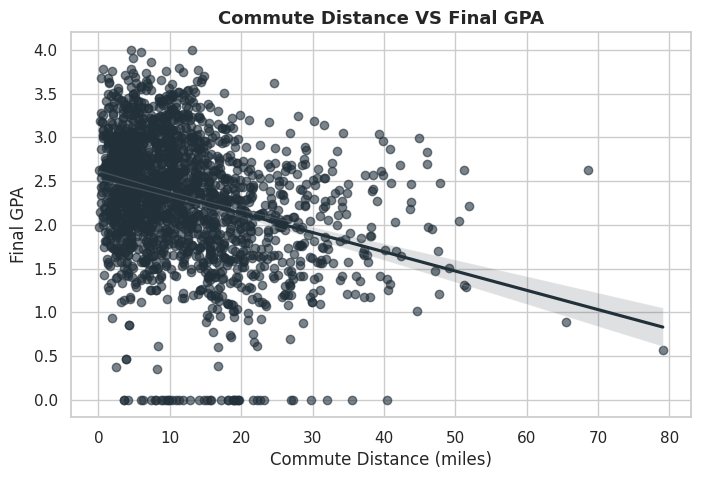

In [41]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa",
            scatter_kws={"alpha":0.6}, color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("Commute Distance VS Final GPA")
ax.set_xlabel("Commute Distance (miles)")
ax.set_ylabel("Final GPA")
plt.show()

# --- your code below ---


**STAR story — Q4** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students) This chart shows the relationship between students commute distance and their final GPA. Each point represents one student's commute miles and GPA.
- **Track —** which question are you answering? Is there a relationship between students commute distance and their GPA? I'm looking for patterns that show how GPA changes as commute distance grows.
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend) The chart shows a negative trend. As the commute distance increases their GPA's decrease.
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)* Students with longer commutes may need additional support to help maintain strong academic performances.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

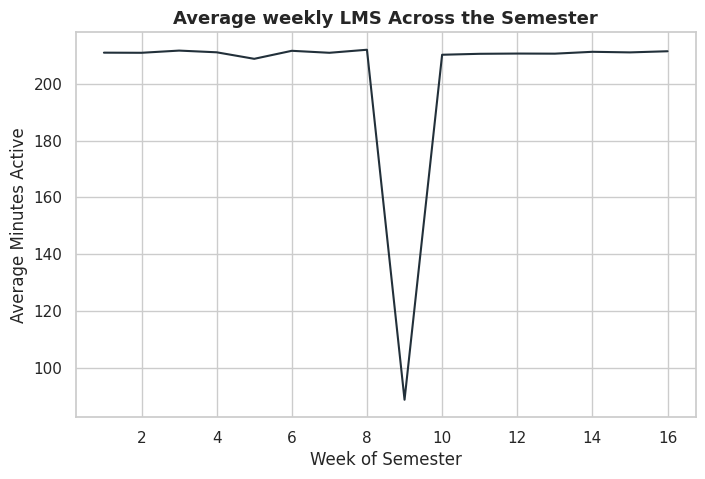

In [42]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.

weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()

fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("Average weekly LMS Across the Semester")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Average Minutes Active")
plt.show()

# --- your code below ---


**STAR story — Q5** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students) This chart shows how average weekly LMS activity changes throughout the semester
- **Track —** which question are you answering? Im examining whether student engagement stays consistent or shifts at specific points in the semester
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend) The graph shows steady activity around 210 minutes per week with a sharp drop near mid-semester followed by a quick recovery
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)* This mid-semester dip may indicate a break or reduced engagement period, suggesting instructors could reinforce supprort or reminders during that week

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** Do students who wek more hours tend to engage less in the LMS during mid-semester?



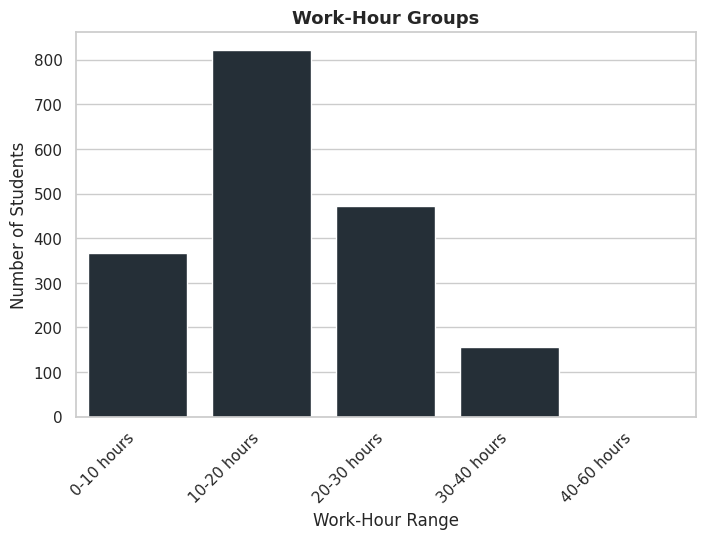

In [44]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.

students["work_group"] = pd.cut(
  students["work_hours_per_week"],
  bins=[0, 10, 20, 30, 40, 60],
  labels=
   ["0-10 hours",
    "10-20 hours",
    "20-30 hours",
    "30-40 hours",
    "40-60 hours",
    ]
)

work_group_counts = students["work_group"].value_counts().sort_index()


fig, ax = plt.subplots()
sns.barplot(data=work_group_counts.reset_index(),
            x="work_group", y="count", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("Work-Hour Groups")
ax.set_xlabel("Work-Hour Range")
ax.set_ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.show()

**STAR story — Part B** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students) This chart shows how many students fall into each weekly work-hour range
- **Track —** which question are you answering? Im determining how student work hours are distributed across the defined groups.
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend) Most students work between 10-20 hours per week, with fewer students in both lower and higher ranges
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)* Students working longer hours may need additional academic support ot flexibility to help balance.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.